# Flow2BT: trajectory rollout and agglomerative clustering

Minimal matplotlib walk-through of Subsystems 2-3
(`survey/design/02_teacher_flow_policy.md`, `survey/design/03_topological_induction_bifurcations.md`)
on the pretrained flow teacher, reusing `src/induce_flow2bt.py` and `src/flow2bt/clustering.py`.

1. **Rollout** -- sample `K` futures per conditioning state by integrating the learned velocity
   field from noise (`t=0`) to a 2 s future (`t=1`), keeping every ODE step.
2. **Clustering** -- rotate the ensemble into the navmesh frame, lift it so Euclidean distance equals the
   design's metric `D` (position + terminal + velocity), run Ward, cut to `B=8` leaves.

In [1]:
import os
import sys
from pathlib import Path

REPO = Path.cwd().resolve().parent if Path.cwd().name == "experiments" else Path.cwd().resolve()
sys.path.insert(0, str(REPO))
os.chdir(REPO)

import matplotlib.pyplot as plt
import numpy as np
import torch
from hydra import compose, initialize_config_dir
from scipy.cluster.hierarchy import dendrogram as scipy_dendrogram

from src.data.dotdict_bridge import to_crowdes_config
from src.flow2bt.assembly import name_leaves_by_geometry
from src.flow2bt.clustering import induce, leaf_dispersion, leaf_prototypes, suggest_num_leaves
from src.induce_flow2bt import gather_batch, load_dataset, load_teacher, nav_frame_rotation, to_nav_frame
from flow_matching.solver import ODESolver

CKPT = "outputs/flow_eth/20261005-121114/checkpoints/epoch063-minfde0.0529.ckpt"
NUM_STATES, K, NUM_LEAVES, SEED = 1024, 16, 8, 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Categorical slots in fixed order, one per leaf.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
                     "axes.edgecolor": "#8a8984", "axes.labelcolor": "#52514e",
                     "xtick.color": "#52514e", "ytick.color": "#52514e"})

I0000 00:00:1791274397.006194 3102513 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791274397.039647 3102513 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791274397.821969 3102513 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Data and pretrained flow teacher

In [2]:
with initialize_config_dir(config_dir=str(REPO / "src/configs"), version_base="1.3"):
    cfg = compose("induce", overrides=["data=eth"])
crowdes_cfg = to_crowdes_config(cfg.data)
sim_cfg = crowdes_cfg["crowd_simulator"]["simulator"]
dt = 1.0 / float(sim_cfg["simulator_fps"])

dataset = load_dataset(crowdes_cfg, "train")
rng = np.random.default_rng(SEED)
indices = rng.choice(len(dataset), size=NUM_STATES, replace=False)
batch = gather_batch(dataset, indices)
teacher = load_teacher("flow", CKPT, DEVICE)
print(f"{len(dataset)} train windows -> {NUM_STATES} states; ODE: {teacher.ode_steps} x {teacher.ode_method}")

2235104 train windows -> 1024 states; ODE: 5 x midpoint


## 1. Trajectory rollout

Same sampling path as `FlowMatchingSimulator.forward(sampling=True)`: encode the state, draw the B=8
behaviour latent, then solve `dx/dt = v(x, t | state, latent)`. The only change is
`return_intermediates=True`, so every flow-time step `x_t` is kept.

In [3]:
@torch.no_grad()
def rollout(model, batch, k, seed=0):
    """Returns flow paths (N, k, S+1, T, 2) and the sampled latent (N, k)."""
    torch.manual_seed(seed)
    b = {key: value.to(DEVICE) for key, value in batch.items()}
    emb = model._context(b["traj_hist"], b["goal"], b["attr"], b["control"].clone(),
                         b["neighbor"], b["environment"])
    logits = model._latent_logits(emb).repeat_interleave(k, 0)
    latent = torch.distributions.OneHotCategorical(logits=logits).sample()
    cond = torch.cat([emb.repeat_interleave(k, 0), latent], dim=1)

    x_0 = torch.randn(len(cond), model.data_dim, device=DEVICE)
    solver = ODESolver(velocity_model=lambda x, t, **_: model.velocity(x, t, cond))
    paths = solver.sample(x_init=x_0, step_size=1.0 / model.ode_steps, method=model.ode_method,
                          time_grid=torch.linspace(0, 1, model.ode_steps + 1, device=DEVICE),
                          return_intermediates=True)                       # (S+1, N*k, T*2)
    n, steps = len(emb), len(paths)
    paths = paths.view(steps, n, k, -1, 2).permute(1, 2, 0, 3, 4)
    return paths.cpu().numpy(), latent.argmax(1).view(n, k).cpu().numpy()

flow_paths, latents = rollout(teacher, batch, K, seed=SEED)
futures = flow_paths[:, :, -1]                                             # (N, K, T, 2) at t=1
flow_times = np.linspace(0, 1, flow_paths.shape[2])
print("flow paths", flow_paths.shape)

flow paths (1024, 16, 6, 10, 2)


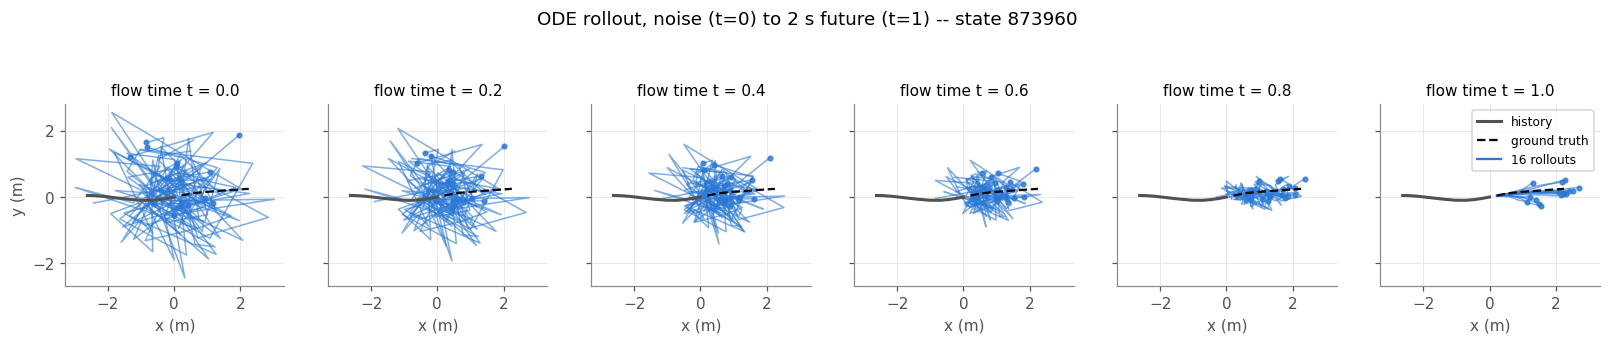

In [4]:
s = 0  # conditioning state to show
hist, gt, control = (batch[key][s].numpy() for key in ("traj_hist", "traj_fut", "control"))

fig, axes = plt.subplots(1, len(flow_times), figsize=(3.0 * len(flow_times), 3.2), sharex=True, sharey=True)
for ax, step, t in zip(axes, range(len(flow_times)), flow_times):
    for x in flow_paths[s, :, step]:
        ax.plot(x[:, 0], x[:, 1], color=PALETTE[0], lw=1, alpha=0.6)
        ax.plot(*x[-1], "o", color=PALETTE[0], ms=3, alpha=0.8)
    ax.plot(hist[:, 0], hist[:, 1], color="#52514e", lw=2)
    ax.plot(gt[:, 0], gt[:, 1], "--", color="#0b0b0b", lw=1.5)
    ax.set_title(f"flow time t = {t:.1f}", fontsize=10)
    ax.set_aspect("equal")
axes[0].set_ylabel("y (m)")
for ax in axes:
    ax.set_xlabel("x (m)")
axes[-1].plot([], [], color="#52514e", lw=2, label="history")
axes[-1].plot([], [], "--", color="#0b0b0b", label="ground truth")
axes[-1].plot([], [], color=PALETTE[0], label=f"{K} rollouts")
axes[-1].legend(fontsize=8, loc="best")
fig.suptitle(f"ODE rollout, noise (t=0) to 2 s future (t=1) -- state {indices[s]}", y=1.02)
plt.show()

## 2. Agglomerative (Ward) clustering

`induce` lifts each trajectory to `phi(xi) = [xi*sqrt(dt), sqrt(l_term)*xi(T), xi'*sqrt(l_vel*dt)]`, so
Ward runs on exact Euclidean inputs, then cuts the tree to `NUM_LEAVES`. The ensemble is first rotated
so each agent's navmesh waypoint lies along +x, as in `src/induce_flow2bt.py`.

In [5]:
rotation = np.repeat(nav_frame_rotation(batch["control"].numpy()), K, axis=0)
bundle = to_nav_frame(futures.reshape(-1, *futures.shape[-2:]), rotation)   # (N*K, T, 2)

tree = induce(bundle, dt, num_leaves=NUM_LEAVES, lambda_term=float(cfg.lambda_term),
              lambda_vel=float(cfg.lambda_vel), min_branch=int(cfg.min_branch))
prototypes = leaf_prototypes(bundle, tree.labels)
dispersion = leaf_dispersion(bundle, tree.labels)
names = name_leaves_by_geometry(prototypes)
elbow = suggest_num_leaves(tree.linkage_matrix)
print(f"{len(bundle)} trajectories -> {tree.num_leaves} leaves, {len(tree.bifurcations)} bifurcations "
      f"(elbow suggests {elbow})")

16384 trajectories -> 8 leaves, 7 bifurcations (elbow suggests 2)


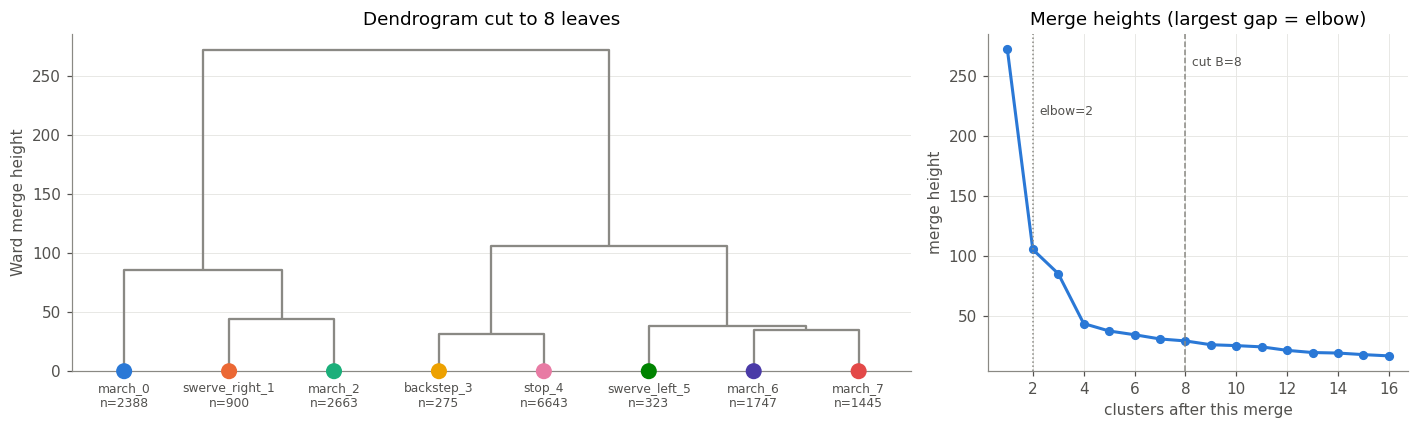

In [6]:
fig, (ax_tree, ax_gap) = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [2, 1]})

d = scipy_dendrogram(tree.linkage_matrix, truncate_mode="lastp", p=NUM_LEAVES, ax=ax_tree,
                     link_color_func=lambda _: "#8a8984", no_labels=True)
leaf_order = [tree.node_to_leaf[node] for node in d["leaves"]]
xs = 5 + 10 * np.arange(len(leaf_order))
ax_tree.scatter(xs, np.zeros_like(xs), s=90, c=[PALETTE[l] for l in leaf_order], zorder=3, clip_on=False)
ax_tree.set_xticks(xs, [f"{names[l]}\nn={len(tree.leaf_members[l])}" for l in leaf_order], fontsize=8)
ax_tree.set_ylabel("Ward merge height")
ax_tree.set_title(f"Dendrogram cut to {NUM_LEAVES} leaves")
ax_tree.grid(axis="x", visible=False)

heights = tree.linkage_matrix[::-1, 2][:16]
clusters = np.arange(1, len(heights) + 1)
ax_gap.plot(clusters, heights, "-o", color=PALETTE[0], lw=2, ms=5)
ax_gap.axvline(NUM_LEAVES, color="#8a8984", ls="--", lw=1)
ax_gap.axvline(elbow, color="#8a8984", ls=":", lw=1)
ax_gap.annotate(f"cut B={NUM_LEAVES}", (NUM_LEAVES, heights.max()), xytext=(4, -4),
                textcoords="offset points", fontsize=8, color="#52514e", va="top")
ax_gap.annotate(f"elbow={elbow}", (elbow, heights.max() * 0.85), xytext=(4, -4),
                textcoords="offset points", fontsize=8, color="#52514e", va="top")
ax_gap.set_xlabel("clusters after this merge")
ax_gap.set_ylabel("merge height")
ax_gap.set_title("Merge heights (largest gap = elbow)")
fig.tight_layout()
plt.show()

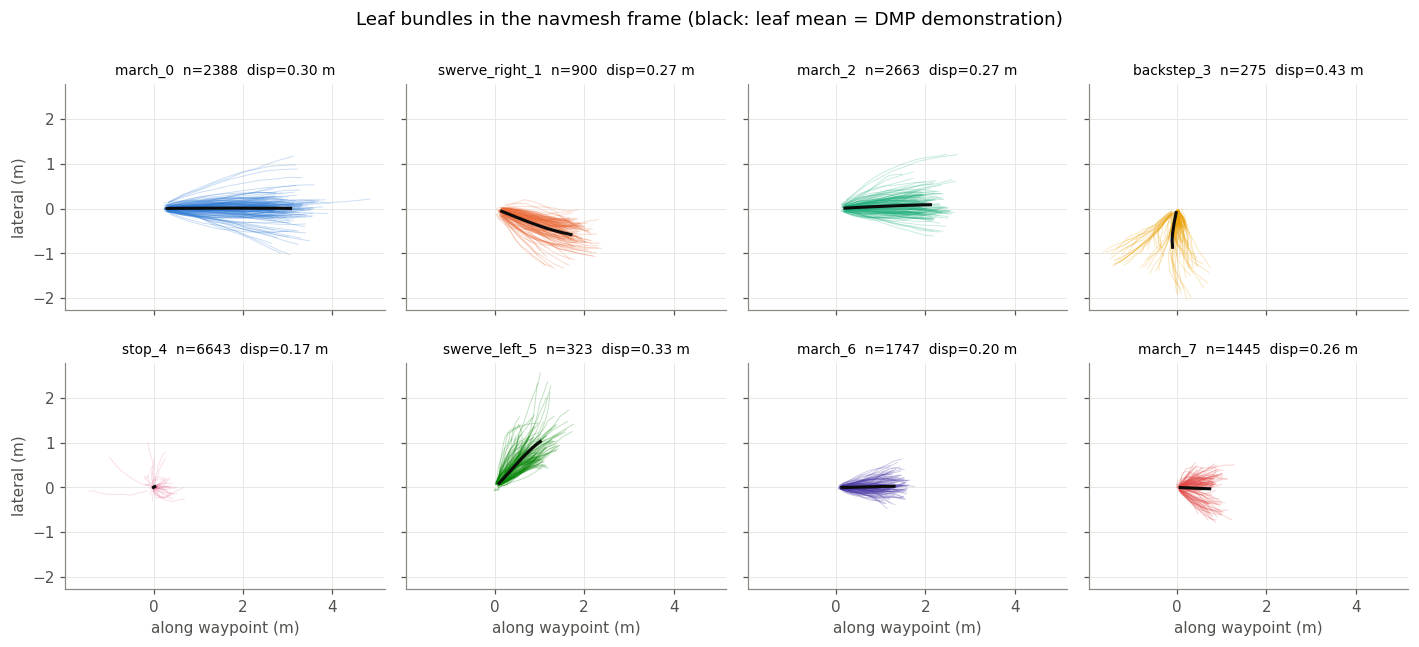

In [7]:
fig, axes = plt.subplots(2, NUM_LEAVES // 2, figsize=(13, 6), sharex=True, sharey=True)
for ax, leaf in zip(axes.flat, sorted(prototypes)):
    members = tree.leaf_members[leaf]
    shown = rng.choice(members, size=min(150, len(members)), replace=False)
    for traj in bundle[shown]:
        ax.plot(traj[:, 0], traj[:, 1], color=PALETTE[leaf], lw=0.6, alpha=0.25)
    ax.plot(prototypes[leaf][:, 0], prototypes[leaf][:, 1], color="#0b0b0b", lw=2)
    ax.set_title(f"{names[leaf]}  n={len(members)}  disp={dispersion[leaf]:.2f} m", fontsize=9)
    ax.set_aspect("equal")
for ax in axes[-1]:
    ax.set_xlabel("along waypoint (m)")
for ax in axes[:, 0]:
    ax.set_ylabel("lateral (m)")
fig.suptitle("Leaf bundles in the navmesh frame (black: leaf mean = DMP demonstration)")
fig.tight_layout()
plt.show()

## 3. Bifurcation within one state

The point of a generative teacher is many futures per state. States whose `K` rollouts spread over the most
leaves are where the dendrogram's splits show up as a decision.

In [ ]:
per_state = tree.labels.reshape(NUM_STATES, K)
spread = np.array([len(np.unique(row)) for row in per_state])
picks = np.argsort(-spread, kind="stable")[:4]

fig, axes = plt.subplots(1, len(picks), figsize=(13, 3.6), sharex=True, sharey=True)
for ax, s in zip(axes, picks):
    trajs = bundle.reshape(NUM_STATES, K, -1, 2)[s]
    for leaf in np.unique(per_state[s]):
        for j, traj in enumerate(trajs[per_state[s] == leaf]):
            ax.plot(traj[:, 0], traj[:, 1], color=PALETTE[leaf], lw=1.2, alpha=0.8,
                    label=names[leaf] if j == 0 else None)
    ax.plot(0, 0, "o", color="#0b0b0b", ms=4)
    ax.set_title(f"state {indices[s]}: {spread[s]} leaves", fontsize=9)
    ax.set_xlabel("along waypoint (m)")
    ax.set_aspect("equal")
    ax.legend(fontsize=7, loc="best")
axes[0].set_ylabel("lateral (m)")
fig.tight_layout()
plt.show()